In [2]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings

In [3]:
def validate_trajectory(u):
    """Validate trajectory and box dimensions"""
    print(f"Total frames: {len(u.trajectory)}")
    print(f"Timestep: {u.trajectory.dt} fs")
    
    # Check box dimensions
    u.trajectory[0]
    box = u.dimensions[:3]
    print(f"Box dimensions: {box} Å")
    
    # Check if box is roughly cubic
    if not np.allclose(box, box[0], rtol=0.01):
        warnings.warn("Box is not cubic. This may affect the analysis.")
    
    return box

def apply_minimum_image(disp, box):
    """Apply minimum image convention for periodic boundary conditions"""
    return disp - box * np.round(disp / box)


In [4]:
# Load universe
u = mda.Universe("./py/400.lammpstrj", format="LAMMPSDUMP", dt=2.0)

# Mapping from atom types to elements
type_to_element = {1: 'S', 2: 'F', 3: 'O', 4: 'N', 5: 'C', 6: 'Li', 7: 'Co', 8: 'H'}

# Add 'element' as a new attribute to each atom
atom_types = u.atoms.types.astype(int)
elements = np.array([type_to_element[t] for t in atom_types])
u.add_TopologyAttr('element', elements)

# Select Li atoms
li = u.select_atoms("element Li")
print(f"Number of Li atoms: {len(li)}")
print("First few Li atom indices:", li.indices[:5])

# Validate trajectory
box = validate_trajectory(u)

/home/ram/software/miniconda3/lib/python3.12/site-packages/MDAnalysis/topology/LAMMPSParser.py:637: UserWarning: Guessed all Masses to 1.0
  warnings.warn('Guessed all Masses to 1.0')


Number of Li atoms: 48
First few Li atom indices: [15 31 47 63 79]
Total frames: 1501
Timestep: 2.0 fs
Box dimensions: [32.548252 32.979584 38.31419 ] Å


/tmp/ipykernel_66505/2073403944.py:13: UserWarning: Box is not cubic. This may affect the analysis.
  warnings.warn("Box is not cubic. This may affect the analysis.")


In [5]:
max_r = min(box) / 2  # Use half the smallest box dimension to avoid double counting
n_bins = 2000
bin_edges = np.linspace(0, max_r, n_bins + 1)
r = 0.5 * (bin_edges[:-1] + bin_edges[1:])  # Bin centers
dr = bin_edges[1] - bin_edges[0]

# Consistent time lags throughout the analysis
time_lags = [10, 100, 300, 500, 700, 900]
n_frames = len(u.trajectory)
n_particles = len(li)

print(f"Analysis parameters:")
print(f"  Max r: {max_r:.2f} Å")
print(f"  Bin width: {dr:.4f} Å")
print(f"  Time lags: {time_lags}")
print(f"  Available frames: {n_frames}")

Analysis parameters:
  Max r: 16.27 Å
  Bin width: 0.0081 Å
  Time lags: [10, 100, 300, 500, 700, 900]
  Available frames: 1501


In [6]:
def calculate_self_van_hove(u, li, time_lags, bin_edges):
    """
    Calculate the self-part of the van Hove correlation function.
    G_self(r,t) = <δ(r - |r_i(t) - r_i(0)|)>
    """
    n_bins = len(bin_edges) - 1
    n_particles = len(li)
    n_frames = len(u.trajectory)
    
    results = {lag: np.zeros(n_bins) for lag in time_lags}
    
    print("Computing self-part of van Hove function...")
    
    for i in tqdm(range(n_frames - max(time_lags))):
        u.trajectory[i]
        ref_pos = li.positions.copy()
        box = u.dimensions[:3]
        
        for lag in time_lags:
            u.trajectory[i + lag]
            cur_pos = li.positions.copy()
            
            # Calculate displacement with minimum image convention
            disp = cur_pos - ref_pos
            disp = apply_minimum_image(disp, box)
            
            # Calculate distances
            dist = np.linalg.norm(disp, axis=1)
            
            # Histogram and accumulate
            hist, _ = np.histogram(dist, bins=bin_edges)
            results[lag] += hist
    
    return results


In [7]:
def calculate_distinct_van_hove(u, li, time_lags, bin_edges):
    """
    Calculate the distinct-part of the van Hove correlation function.
    G_distinct(r,t) = <δ(r - |r_j(t) - r_i(0)|)> where i≠j
    """
    n_bins = len(bin_edges) - 1
    n_particles = len(li)
    n_frames = len(u.trajectory)
    
    results = {lag: np.zeros(n_bins) for lag in time_lags}
    
    print("Computing distinct-part of van Hove function...")
    
    for frame_idx in tqdm(range(n_frames - max(time_lags))):
        u.trajectory[frame_idx]
        ref_pos = li.positions.copy()
        box = u.dimensions[:3]
        
        for lag in time_lags:
            u.trajectory[frame_idx + lag]
            cur_pos = li.positions.copy()
            
            # Vectorized calculation of all i,j pairs where i≠j
            distances = []
            
            for i in range(n_particles):
                for j in range(n_particles):
                    if i != j:
                        # Distance from particle j at time t to particle i at time 0
                        disp = cur_pos[j] - ref_pos[i]
                        disp = apply_minimum_image(disp, box)
                        dist = np.linalg.norm(disp)
                        distances.append(dist)
            
            # Histogram and accumulate
            hist, _ = np.histogram(distances, bins=bin_edges)
            results[lag] += hist
    
    return results

In [8]:
self_results = calculate_self_van_hove(u, li, time_lags, bin_edges)

# Calculate distinct-part
distinct_results = calculate_distinct_van_hove(u, li, time_lags, bin_edges)
self_results = calculate_self_van_hove(u, li, time_lags, bin_edges)

# Calculate distinct-part
distinct_results = calculate_distinct_van_hove(u, li, time_lags, bin_edges)


Computing self-part of van Hove function...


100%|██████████| 601/601 [00:18<00:00, 31.91it/s]


Computing distinct-part of van Hove function...


100%|██████████| 601/601 [00:46<00:00, 12.81it/s]


Computing self-part of van Hove function...


100%|██████████| 601/601 [00:18<00:00, 31.97it/s]


Computing distinct-part of van Hove function...


100%|██████████| 601/601 [00:47<00:00, 12.78it/s]


In [9]:
def normalize_van_hove_results(results, time_lags, r, dr, n_particles, n_frames, result_type='self'):
    """
    Normalize van Hove correlation function results.
    
    Parameters:
    - results: Dictionary of histograms for each time lag
    - time_lags: List of time lags
    - r: Bin centers
    - dr: Bin width
    - n_particles: Number of particles
    - n_frames: Number of frames
    - result_type: 'self' or 'distinct'
    """
    # Shell volumes for spherical normalization
    shell_volumes = 4 * np.pi * r**2 * dr
    
    # Avoid division by zero at r=0
    shell_volumes[0] = 4 * np.pi * (dr/2)**2 * dr
    
    normalized_results = {}
    
    for lag in time_lags:
        n_time_origins = n_frames - lag
        
        if result_type == 'self':
            # Self-part normalization
            normalization = n_particles * n_time_origins * shell_volumes
        elif result_type == 'distinct':
            # Distinct-part normalization
            normalization = n_particles * (n_particles - 1) * n_time_origins * shell_volumes
        else:
            raise ValueError("result_type must be 'self' or 'distinct'")
        
        normalized_results[lag] = results[lag] / normalization
    
    return normalized_results

In [10]:
self_normalized = normalize_van_hove_results(
    self_results, time_lags, r, dr, n_particles, n_frames, 'self'
)

distinct_normalized = normalize_van_hove_results(
    distinct_results, time_lags, r, dr, n_particles, n_frames, 'distinct'
)

In [11]:
def save_van_hove_data(r, results, time_lags, filename, data_type):
    """Save van Hove data to file with proper headers"""
    output = np.column_stack([r] + [results[lag] for lag in time_lags])
    header = f"r (Å) " + " ".join([f"G_{data_type}(r, t={lag})" for lag in time_lags])
    np.savetxt(filename, output, header=header, fmt="%.8e")
    print(f"Saved: {filename}")


In [12]:
# Save normalized data
save_van_hove_data(r, self_normalized, time_lags, "g_self_rt.dat", "self")
save_van_hove_data(r, distinct_normalized, time_lags, "g_distinct_rt.dat", "distinct")

Saved: g_self_rt.dat
Saved: g_distinct_rt.dat


In [13]:
def plot_van_hove_function(r, results, time_lags, title, ylabel, filename=None):
    """Plot van Hove correlation function"""
    plt.figure(figsize=(10, 6))
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(time_lags)))
    
    for i, lag in enumerate(time_lags):
        plt.plot(r, results[lag], label=f't = {lag}', color=colors[i], linewidth=2)
    
    plt.xlabel(r'$r$ (Å)', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, min(10, max(r)))
    
    # Use log scale for self-part, linear for distinct-part
    if 'self' in title.lower():
        plt.yscale('log')
    
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()

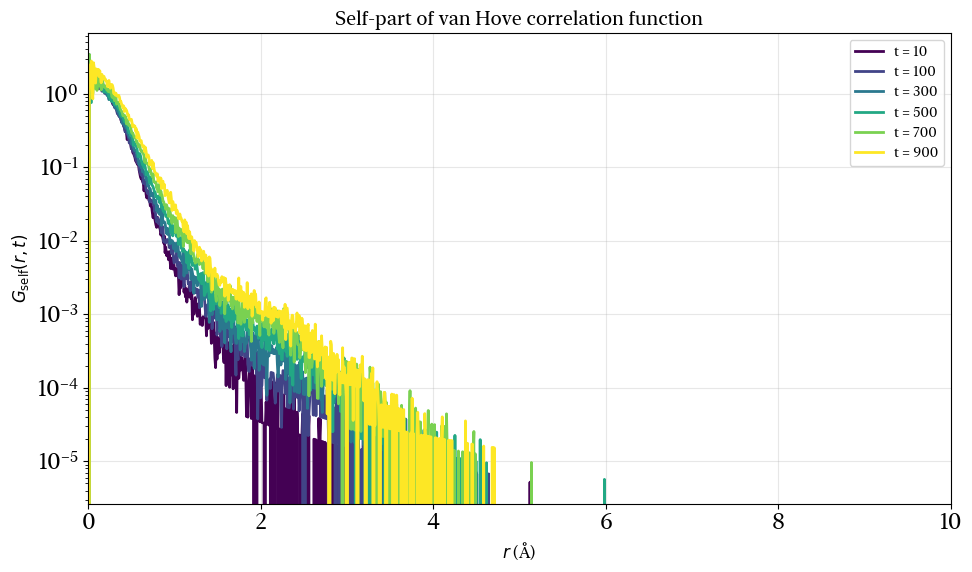

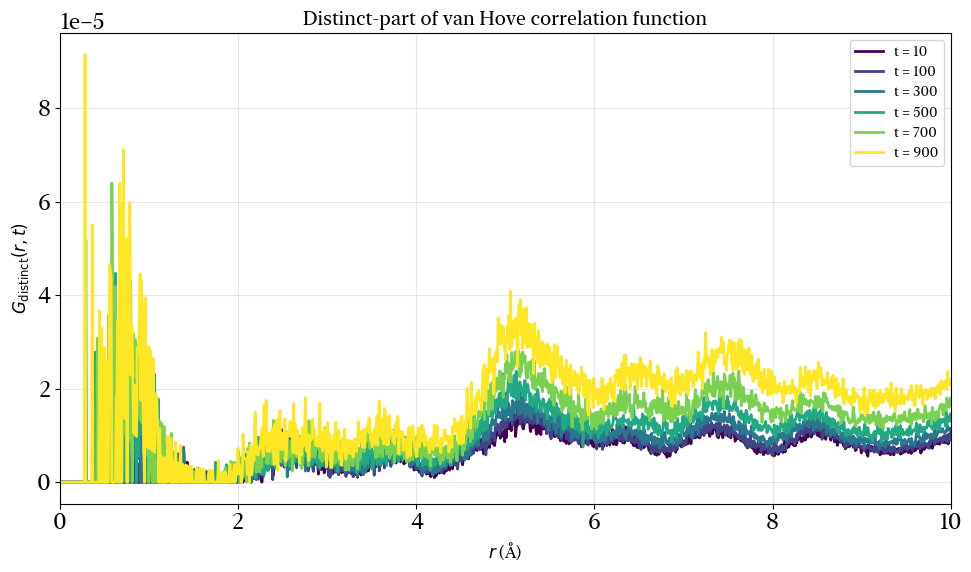

In [14]:
plot_van_hove_function(
    r, self_normalized, time_lags,
    'Self-part of van Hove correlation function',
    r'$G_{\mathrm{self}}(r, t)$',
    'van_hove_self.png'
)

plot_van_hove_function(
    r, distinct_normalized, time_lags,
    'Distinct-part of van Hove correlation function',
    r'$G_{\mathrm{distinct}}(r, t)$',
    'van_hove_distinct.png'
)

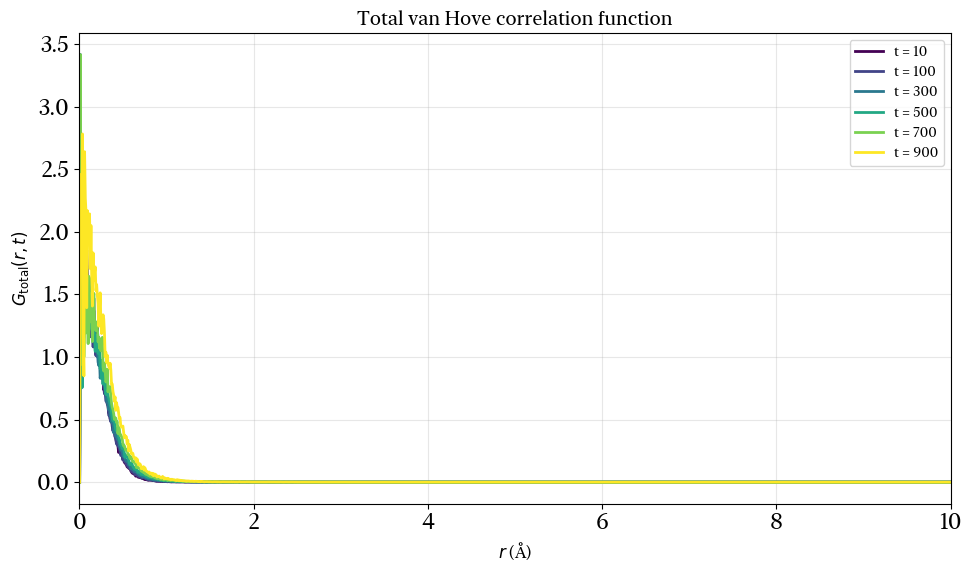


=== Analysis Summary ===
System: 48 Li atoms
Time lags analyzed: [10, 100, 300, 500, 700, 900]
Spatial resolution: 0.0081 Å
Maximum distance: 16.27 Å
Self-part integral (t=10): 0.403 (should be ~1.0)
Self-part integral (t=100): 0.429 (should be ~1.0)
Self-part integral (t=300): 0.500 (should be ~1.0)
Self-part integral (t=500): 0.600 (should be ~1.0)
Self-part integral (t=700): 0.750 (should be ~1.0)
Self-part integral (t=900): 1.000 (should be ~1.0)

Files saved:
- g_self_rt.dat: Self-part van Hove function
- g_distinct_rt.dat: Distinct-part van Hove function
- van_hove_self.png: Self-part plot
- van_hove_distinct.png: Distinct-part plot
- van_hove_total.png: Total van Hove function plot


/tmp/ipykernel_66505/3625251007.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_self = np.trapz(4 * np.pi * r**2 * self_normalized[lag], r)


In [15]:
# Calculate and plot total van Hove function
total_results = {}
for lag in time_lags:
    total_results[lag] = self_normalized[lag] + distinct_normalized[lag]

plot_van_hove_function(
    r, total_results, time_lags,
    'Total van Hove correlation function',
    r'$G_{\mathrm{total}}(r, t)$',
    'van_hove_total.png'
)

# %%
# Analysis and validation
print("\n=== Analysis Summary ===")
print(f"System: {n_particles} Li atoms")
print(f"Time lags analyzed: {time_lags}")
print(f"Spatial resolution: {dr:.4f} Å")
print(f"Maximum distance: {max_r:.2f} Å")

# Check normalization (self-part should integrate to 1)
for lag in time_lags:
    # Integration using trapezoidal rule
    integral_self = np.trapz(4 * np.pi * r**2 * self_normalized[lag], r)
    print(f"Self-part integral (t={lag}): {integral_self:.3f} (should be ~1.0)")

print("\nFiles saved:")
print("- g_self_rt.dat: Self-part van Hove function")
print("- g_distinct_rt.dat: Distinct-part van Hove function")
print("- van_hove_self.png: Self-part plot")
print("- van_hove_distinct.png: Distinct-part plot")
print("- van_hove_total.png: Total van Hove function plot")

=== Self-part van Hove Function ===


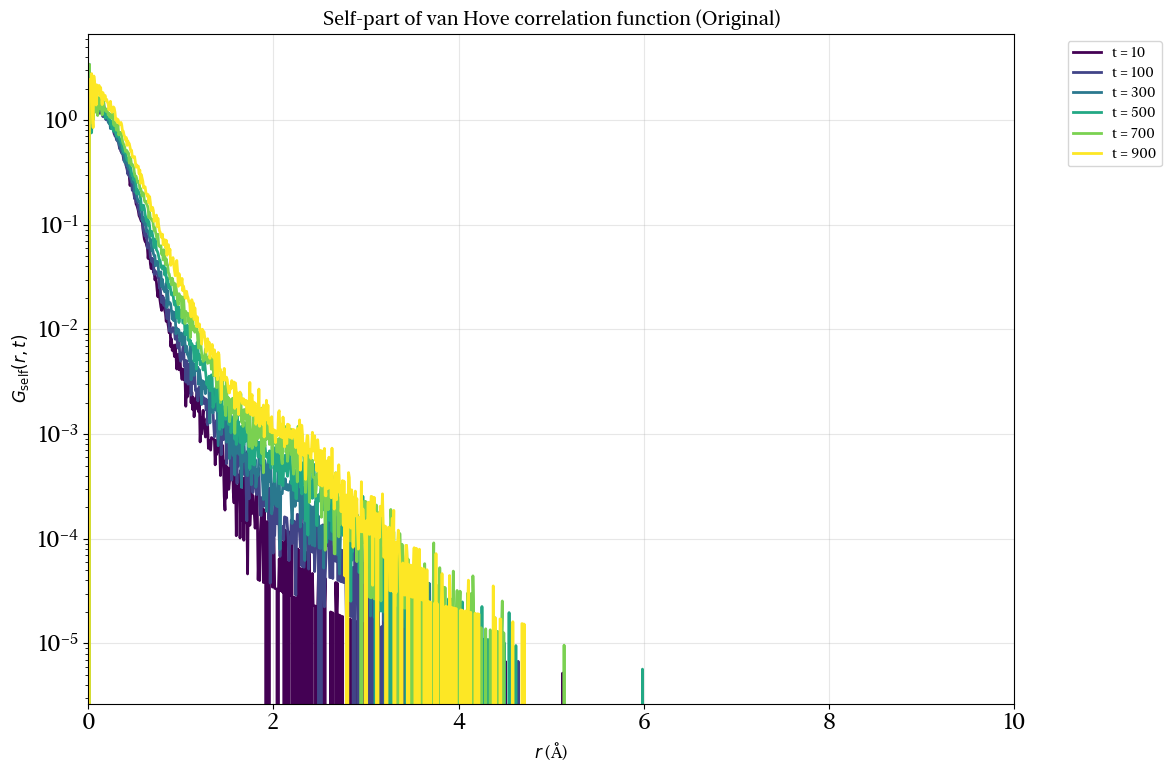

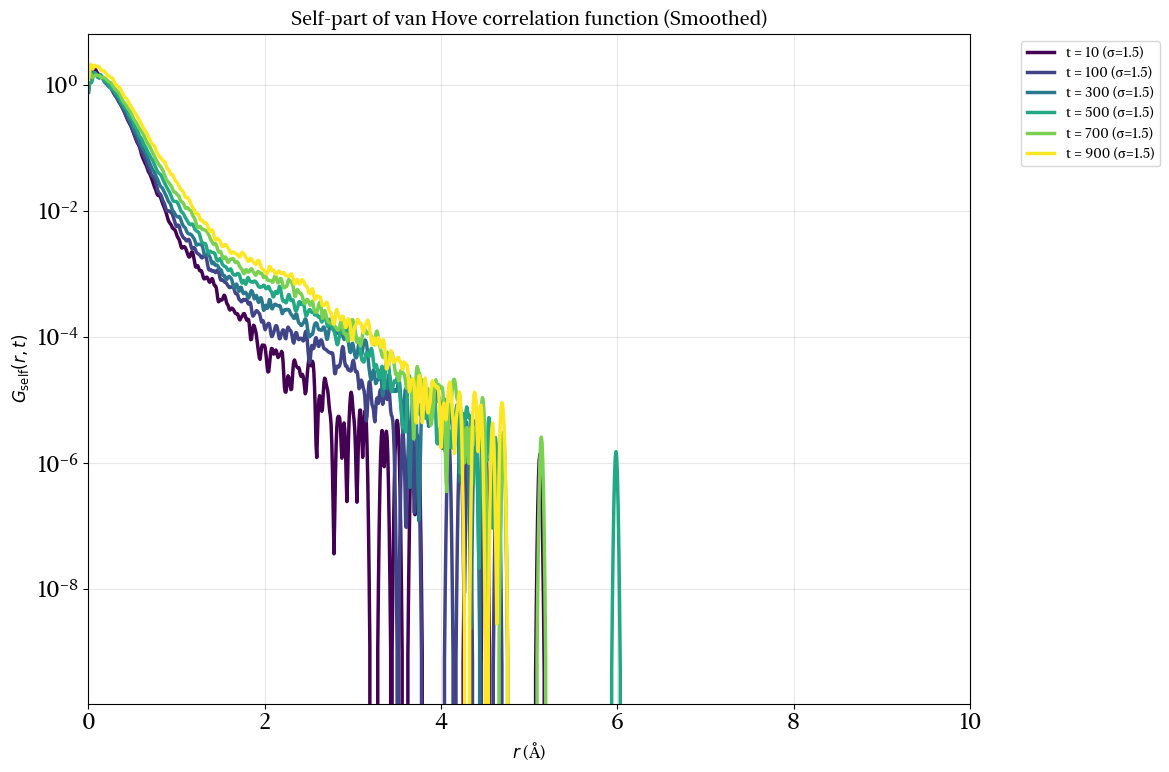

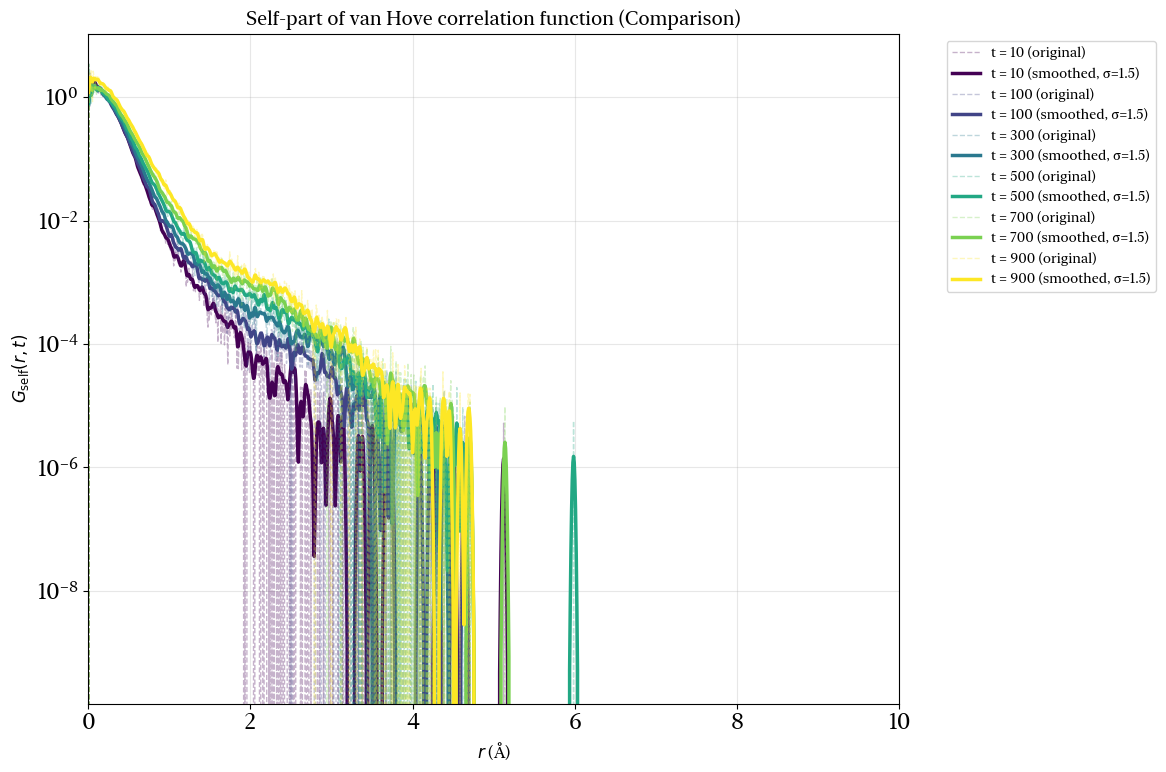

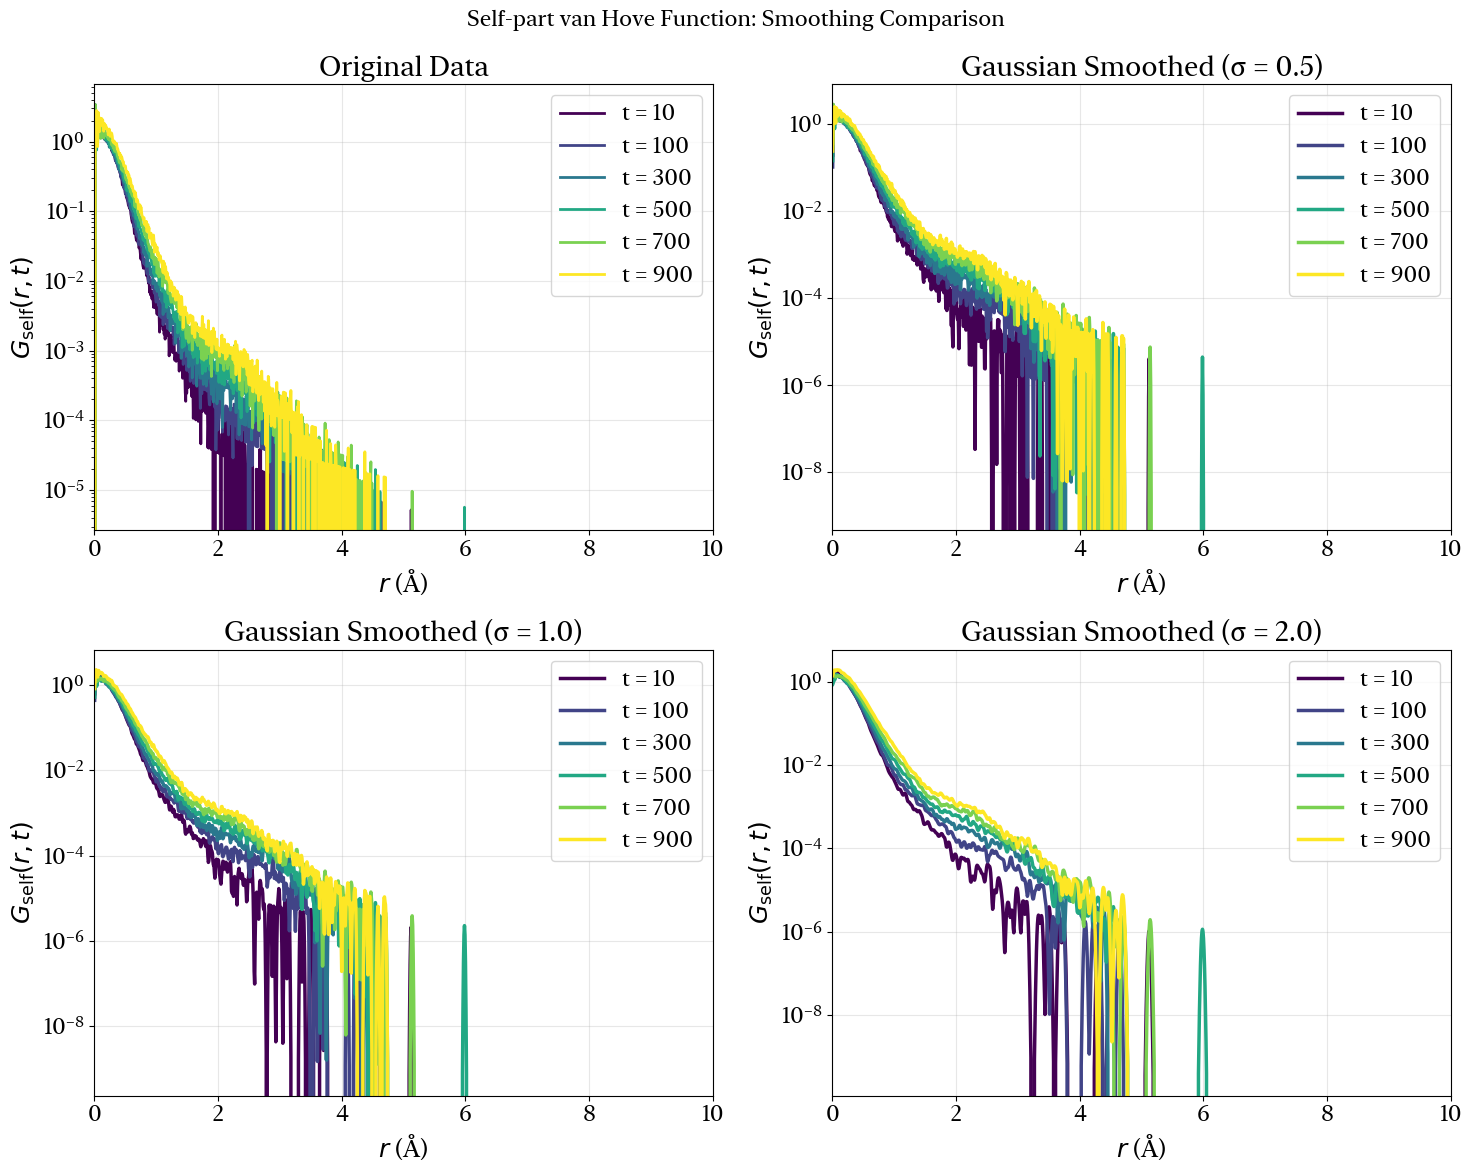


=== Distinct-part van Hove Function ===


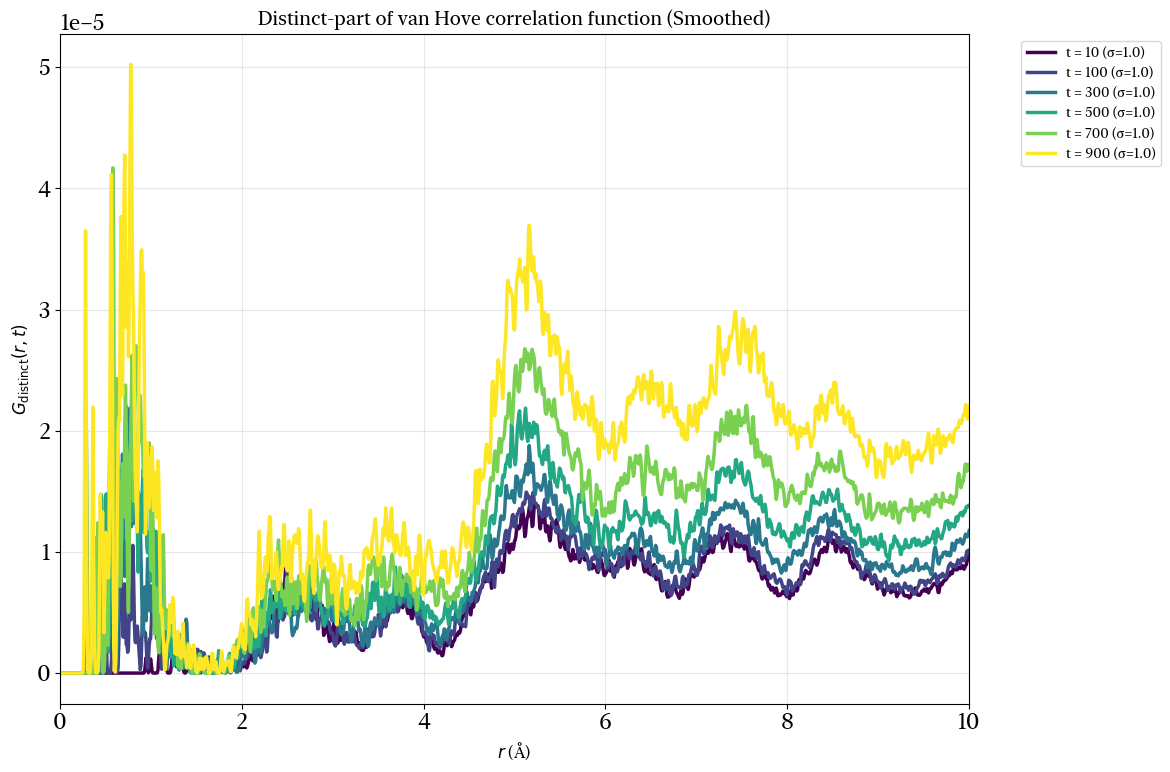

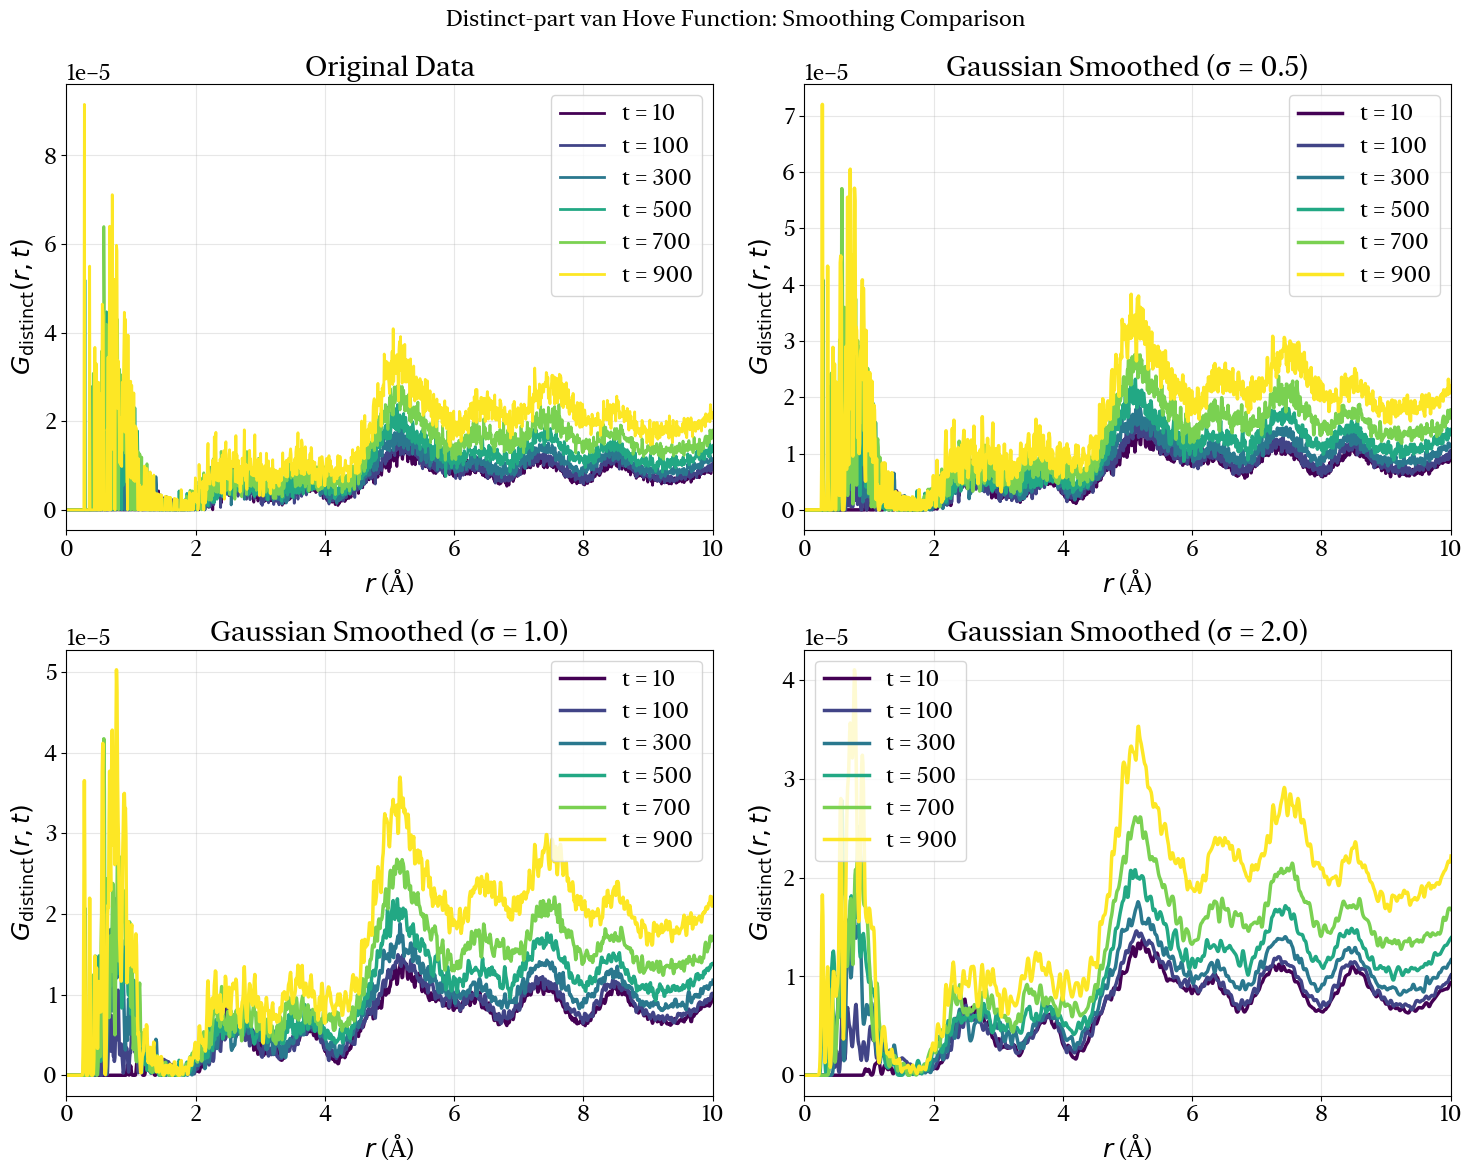


=== Total van Hove Function ===


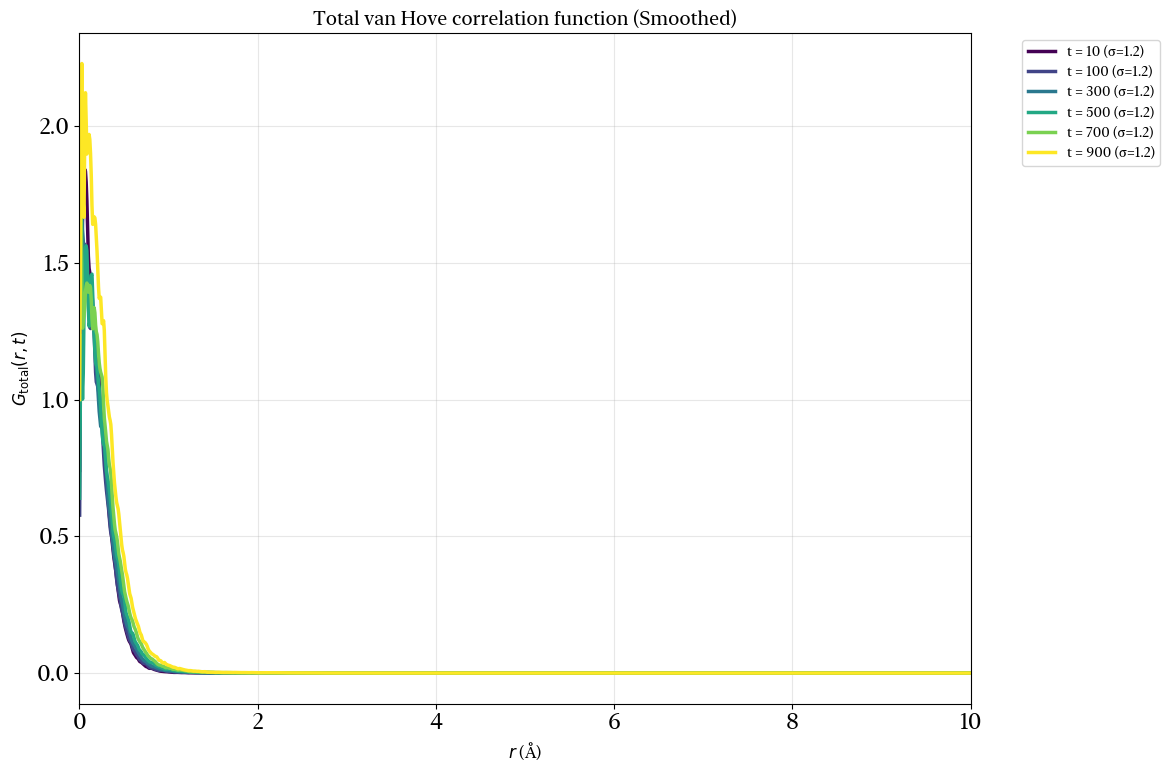

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def gaussian_smooth(data, sigma=1.0):
    """
    Apply Gaussian smoothing to 1D data.
    
    Parameters:
    - data: 1D array to smooth
    - sigma: Standard deviation for Gaussian kernel (larger = more smoothing)
    
    Returns:
    - smoothed_data: Gaussian-smoothed array
    """
    return gaussian_filter1d(data, sigma=sigma)

def plot_van_hove_function(r, results, time_lags, title, ylabel, filename=None, 
                          smooth=False, sigma=1.0, show_original=False):
    """
    Plot van Hove correlation function with optional Gaussian smoothing.
    
    Parameters:
    - r: Radial distance array
    - results: Dictionary of van Hove results for each time lag
    - time_lags: List of time lags
    - title: Plot title
    - ylabel: Y-axis label
    - filename: Optional filename to save plot
    - smooth: Whether to apply Gaussian smoothing
    - sigma: Standard deviation for Gaussian smoothing
    - show_original: Whether to show original data alongside smoothed data
    """
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(time_lags)))
    
    for i, lag in enumerate(time_lags):
        data = results[lag]
        
        if smooth:
            smoothed_data = gaussian_smooth(data, sigma=sigma)
            
            if show_original:
                # Plot original data as thin, transparent line
                plt.plot(r, data, color=colors[i], alpha=0.3, linewidth=1, 
                        linestyle='--', label=f't = {lag} (original)')
                # Plot smoothed data as main line
                plt.plot(r, smoothed_data, color=colors[i], linewidth=2.5, 
                        label=f't = {lag} (smoothed, σ={sigma})')
            else:
                # Plot only smoothed data
                plt.plot(r, smoothed_data, color=colors[i], linewidth=2.5, 
                        label=f't = {lag} (σ={sigma})')
        else:
            # Plot original data only
            plt.plot(r, data, color=colors[i], linewidth=2, label=f't = {lag}')
    
    plt.xlabel(r'$r$ (Å)', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.xlim(0, min(10, max(r)))
    
    # Use log scale for self-part, linear for distinct-part
    if 'self' in title.lower():
        plt.yscale('log')
    
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()

# Enhanced plotting function with multiple smoothing options
def plot_van_hove_comparison(r, results, time_lags, title, ylabel, filename=None, 
                           sigma_values=[0.5, 1.0, 2.0]):
    """
    Plot van Hove function with multiple smoothing levels for comparison.
    
    Parameters:
    - sigma_values: List of smoothing parameters to compare
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)
    
    # Plot original data
    ax = axes[0, 0]
    colors = plt.cm.viridis(np.linspace(0, 1, len(time_lags)))
    for i, lag in enumerate(time_lags):
        ax.plot(r, results[lag], color=colors[i], linewidth=2, label=f't = {lag}')
    ax.set_title('Original Data')
    ax.set_xlabel(r'$r$ (Å)')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, min(10, max(r)))
    if 'self' in title.lower():
        ax.set_yscale('log')
    
    # Plot with different smoothing levels
    for idx, sigma in enumerate(sigma_values):
        ax = axes[(idx+1)//2, (idx+1)%2]
        
        for i, lag in enumerate(time_lags):
            smoothed_data = gaussian_smooth(results[lag], sigma=sigma)
            ax.plot(r, smoothed_data, color=colors[i], linewidth=2.5, 
                   label=f't = {lag}')
        
        ax.set_title(f'Gaussian Smoothed (σ = {sigma})')
        ax.set_xlabel(r'$r$ (Å)')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, min(10, max(r)))
        if 'self' in title.lower():
            ax.set_yscale('log')
    
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()

# Example usage with your van Hove data:

# Plot self-part with different smoothing options
print("=== Self-part van Hove Function ===")

# Original plot
plot_van_hove_function(
    r, self_normalized, time_lags,
    'Self-part of van Hove correlation function (Original)',
    r'$G_{\mathrm{self}}(r, t)$',
    'van_hove_self_original.png'
)

# Smoothed plot only
plot_van_hove_function(
    r, self_normalized, time_lags,
    'Self-part of van Hove correlation function (Smoothed)',
    r'$G_{\mathrm{self}}(r, t)$',
    'van_hove_self_smoothed.png',
    smooth=True, sigma=1.5
)

# Smoothed plot with original data overlay
plot_van_hove_function(
    r, self_normalized, time_lags,
    'Self-part of van Hove correlation function (Comparison)',
    r'$G_{\mathrm{self}}(r, t)$',
    'van_hove_self_comparison.png',
    smooth=True, sigma=1.5, show_original=True
)

# Multiple smoothing comparison
plot_van_hove_comparison(
    r, self_normalized, time_lags,
    'Self-part van Hove Function: Smoothing Comparison',
    r'$G_{\mathrm{self}}(r, t)$',
    'van_hove_self_smoothing_comparison.png',
    sigma_values=[0.5, 1.0, 2.0]
)

print("\n=== Distinct-part van Hove Function ===")

# Similar plots for distinct-part
plot_van_hove_function(
    r, distinct_normalized, time_lags,
    'Distinct-part of van Hove correlation function (Smoothed)',
    r'$G_{\mathrm{distinct}}(r, t)$',
    'van_hove_distinct_smoothed.png',
    smooth=True, sigma=1.0
)

plot_van_hove_comparison(
    r, distinct_normalized, time_lags,
    'Distinct-part van Hove Function: Smoothing Comparison',
    r'$G_{\mathrm{distinct}}(r, t)$',
    'van_hove_distinct_smoothing_comparison.png',
    sigma_values=[0.5, 1.0, 2.0]
)

print("\n=== Total van Hove Function ===")

# Total van Hove with smoothing
plot_van_hove_function(
    r, total_results, time_lags,
    'Total van Hove correlation function (Smoothed)',
    r'$G_{\mathrm{total}}(r, t)$',
    'van_hove_total_smoothed.png',
    smooth=True, sigma=1.2
)
